# Lab 3 — Clustering: What Kind of Student Are You?

**Question.** We have the same 360 students from Lab 2, but this time we
**throw away the grade label.** All we have is their study habits. Can we
still find meaningful groups?

This is **unsupervised learning**: no target, no right answer given to the
model. Instead we ask `K-Means` to discover structure by grouping students
who look similar. Once it has found the clusters, we'll sneak a peek at the
grades we hid — and find out whether the groups it found correspond to real
grade patterns.

> Everything new — cluster, centroid, `StandardScaler`, inertia, silhouette,
> elbow method — is explained from scratch inside this notebook, right before
> you're asked to use it. No prior exposure to unsupervised learning required.


## How to use this lab

Each task follows the same five-beat rhythm as Lab 2:

1. **Concept** — plain-English explainer of the new idea.
2. **Intuition** — a pre-filled cell that draws a picture. *Just run it.*
3. **Predict** — one-line guess before you write any code.
4. **Do** — a `# TODO` cell where you write a few lines yourself. The task
   prompt above it tells you *what* to build and which variable names to
   use. If you're stuck, open the collapsible **Hint 1 → Hint 2 → Hint 3**
   sections one at a time; each reveals more detail, ending with a
   near-solution skeleton.
5. **Verify** — a pre-filled sanity-check cell comparing your numbers to
   expected values, with a 2–3-bullet troubleshooting list.

**Try to write the code yourself before opening a hint.** Hints are there
so you can get unstuck without asking, not so you can skip the thinking.

If something breaks, re-read the last bullet list in the sanity-check cell
before asking for help — that's where the real bugs live.

### Local setup

```bash
conda activate ai101-ml          # same env you used for labs 1 and 2
# or if you're starting fresh:
conda create -n ai101-ml python=3.12 -y && conda activate ai101-ml
python -m pip install numpy pandas matplotlib seaborn scikit-learn jupyter
```


In [1]:
# Imports and plot theme — run once, then forget about this cell.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams.update({
    'figure.dpi': 110,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'legend.frameon': False,
})

COLORS = {
    'blue':   '#3563E9',
    'teal':   '#0F9D8A',
    'orange': '#F28E2B',
    'red':    '#D64545',
    'gold':   '#B88700',
    'slate':  '#5F6C7B',
    'navy':   '#264653',
    'purple': '#8E6BB5',
}

CLUSTER_PALETTE = [COLORS['teal'], COLORS['orange'], COLORS['purple'],
                   COLORS['blue'], COLORS['gold']]

print('Setup complete. Ready to discover student groups.')


Setup complete. Ready to discover student groups.


## 0. Warm-up — K-Means in 3 lines

Before touching student data, let's see K-Means on a toy 2-D problem. The
algorithm takes one decision from you — the number of clusters `k` — and
does everything else itself.

The sklearn workflow is three lines:

```python
model = KMeans(n_clusters=k)
model.fit(X)
labels = model.labels_      # cluster index for each point
```

We'll use three baked blobs of points that are obviously separable so you
can see what "good clustering" looks like.


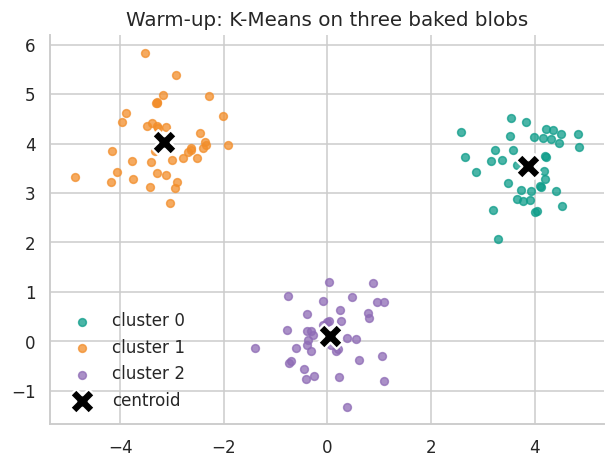

In [2]:
# --- Intuition demo (just run it) ---

rng = np.random.default_rng(0)
centers_true = np.array([[0.0, 0.0], [4.0, 3.5], [-3.0, 4.0]])
blobs = np.vstack([c + rng.normal(0, 0.6, size=(40, 2)) for c in centers_true])

demo_model = KMeans(n_clusters=3, random_state=0, n_init=10)
demo_model.fit(blobs)
demo_labels = demo_model.labels_
demo_centers = demo_model.cluster_centers_

fig, ax = plt.subplots(figsize=(6.5, 4.6))
for i in range(3):
    pts = blobs[demo_labels == i]
    ax.scatter(pts[:, 0], pts[:, 1], s=26, alpha=0.75,
               color=CLUSTER_PALETTE[i], label=f'cluster {i}')
ax.scatter(demo_centers[:, 0], demo_centers[:, 1], s=260, marker='X',
           color='black', edgecolor='white', linewidth=1.5, label='centroid')
ax.set_title('Warm-up: K-Means on three baked blobs')
ax.legend()
plt.show()


**What to notice.** Each colour is a cluster the algorithm discovered.
The big black X is the **centroid** — the mean position of all points in
that cluster. K-Means works by repeatedly answering two questions until
nothing changes:

1. *Which centroid is each point closest to?*  → assign every point to its
   nearest centroid.
2. *Where is the centre of each cluster now?*  → move each centroid to the
   mean of its assigned points.

Repeat until the labels stop changing. That's it.


## 1. The student dataset — same 360 students, no labels

We're reusing the student population from Lab 2, generated with the same
random seed so it's literally the same 360 people. But there's a twist: the
generator for this lab has **three built-in archetypes** — roughly, a
high-effort group, a middle group, and a light-effort group. They were
mixed together and shuffled. The archetype column is hidden from you too;
we'll only peek at it at the very end to see how well K-Means recovered it.

The columns you get to use for clustering:

| Column | Meaning |
|---|---|
| `study_hours_per_week` | Average hours/week studying |
| `attendance_rate_pct` | Share of lectures attended (%) |
| `prior_math_grade` | Danish-scale grade from the previous math course |
| `sleep_hours` | Average nightly sleep (hours) |
| `exercises_completed` | Weekly exercises completed (0–10) |
| `prior_programming_years` | Years of prior programming experience |

The columns we **hide** from K-Means (we'll use them to check its work):

| Column | Meaning |
|---|---|
| `final_score` | Actual exam score, continuous 0–12 |
| `final_grade` | Snapped to the Danish 7-step scale |


In [3]:
# --- Build the dataset. Run this cell; the generator is self-contained. ---

DANISH_SCALE = np.array([-3, 0, 2, 4, 7, 10, 12], dtype=float)

def snap_to_danish(score):
    """Round each score to the nearest Danish grade in {-3, 0, 2, 4, 7, 10, 12}."""
    score = np.asarray(score, dtype=float)
    return DANISH_SCALE[np.argmin(np.abs(score[..., None] - DANISH_SCALE), axis=-1)]

def make_student_profiles(n_students=360, random_state=42):
    rng = np.random.default_rng(random_state)
    # Three baked archetypes with fixed mixing proportions.
    archetype = rng.choice([0, 1, 2], size=n_students, p=[0.35, 0.40, 0.25])
    study = np.empty(n_students); attend = np.empty(n_students)
    prior_math = np.empty(n_students); sleep = np.empty(n_students)
    exercises = np.empty(n_students, dtype=int); prog = np.empty(n_students)

    # Archetype 0 — 'Dedicated achievers'
    m = archetype == 0; k = m.sum()
    study[m]      = rng.normal(12.0, 2.0, k)
    attend[m]     = rng.normal(92.0, 4.5, k)
    prior_math[m] = rng.choice([7, 10, 12], size=k, p=[0.30, 0.50, 0.20])
    sleep[m]      = rng.normal(7.3, 0.5, k)
    exercises[m]  = rng.binomial(10, 0.82, k)
    prog[m]       = rng.exponential(2.2, k)

    # Archetype 1 — 'Moderate middle'
    m = archetype == 1; k = m.sum()
    study[m]      = rng.normal(7.5, 1.8, k)
    attend[m]     = rng.normal(82.0, 7.0, k)
    prior_math[m] = rng.choice([4, 7, 10], size=k, p=[0.30, 0.55, 0.15])
    sleep[m]      = rng.normal(7.0, 0.9, k)
    exercises[m]  = rng.binomial(10, 0.50, k)
    prog[m]       = rng.exponential(1.0, k)

    # Archetype 2 — 'Light effort'
    m = archetype == 2; k = m.sum()
    study[m]      = rng.normal(3.8, 1.8, k)
    attend[m]     = rng.normal(68.0, 9.0, k)
    prior_math[m] = rng.choice([-3, 0, 2, 4], size=k, p=[0.15, 0.30, 0.35, 0.20])
    sleep[m]      = rng.normal(6.3, 1.2, k)
    exercises[m]  = rng.binomial(10, 0.25, k)
    prog[m]       = rng.exponential(0.6, k)

    # Clip everything into realistic ranges.
    study      = np.clip(study, 0.5, 20.0)
    attend     = np.clip(attend, 40.0, 100.0)
    sleep      = np.clip(sleep, 3.0, 10.0)
    prog       = np.clip(prog, 0.0, 6.0)
    prior_math = prior_math.astype(int)

    # Final score follows the same formula as Lab 2 — grades are a
    # by-product of habits (plus noise).
    score = (-3.0
             + 0.45 * study
             + 0.025 * attend
             + 0.35 * prior_math
             - 0.30 * (sleep - 7.2) ** 2
             + 0.18 * exercises
             + 0.30 * prog
             + rng.normal(0.0, 1.0, n_students))
    score = np.clip(score, -3.0, 12.0)

    df = pd.DataFrame({
        'study_hours_per_week':     np.round(study, 1),
        'attendance_rate_pct':      np.round(attend, 1),
        'prior_math_grade':         prior_math,
        'sleep_hours':              np.round(sleep, 1),
        'exercises_completed':      exercises,
        'prior_programming_years':  np.round(prog, 1),
        'final_score':              np.round(score, 2),      # hidden from model
        'final_grade':              snap_to_danish(score).astype(int),  # hidden
        'true_archetype':           archetype,                # hidden
    })
    return df

FEATURE_COLS = [
    'study_hours_per_week',
    'attendance_rate_pct',
    'prior_math_grade',
    'sleep_hours',
    'exercises_completed',
    'prior_programming_years',
]
HIDDEN_COLS = ['final_score', 'final_grade', 'true_archetype']

df = make_student_profiles()
print(f'Dataset shape: {df.shape}')
print('Columns K-Means may use:', FEATURE_COLS)
print('Columns we keep hidden: ', HIDDEN_COLS)
df.head()


Dataset shape: (360, 9)
Columns K-Means may use: ['study_hours_per_week', 'attendance_rate_pct', 'prior_math_grade', 'sleep_hours', 'exercises_completed', 'prior_programming_years']
Columns we keep hidden:  ['final_score', 'final_grade', 'true_archetype']


,study_hours_per_week,attendance_rate_pct,prior_math_grade,sleep_hours,exercises_completed,prior_programming_years,final_score,final_grade,true_archetype
0,3.4,93.7,2,5.0,2,0.9,-1.44,0,2
1,6.1,88.8,4,7.7,2,1.8,3.63,4,1
2,2.5,71.3,2,4.8,2,0.0,0.41,0,2
3,9.8,92.6,4,5.5,4,1.7,6.03,7,1
4,10.8,92.8,10,6.2,8,6.0,10.85,10,0


Summary (just the feature columns K-Means will see):


,study_hours_per_week,attendance_rate_pct,prior_math_grade,sleep_hours,exercises_completed,prior_programming_years
count,360.00,360.00,360.00,360.0,360.00,360.00
mean,8.09,82.07,6.18,6.9,5.53,1.28
std,3.66,11.15,3.81,1.0,2.61,1.35
min,0.50,48.60,-3.00,3.0,0.00,0.00
25%,5.10,73.85,4.00,6.4,3.00,0.30
50%,7.70,84.55,7.00,7.0,6.00,0.80
75%,11.10,90.75,10.00,7.5,8.00,1.80
max,16.70,100.00,12.00,9.6,10.00,6.00


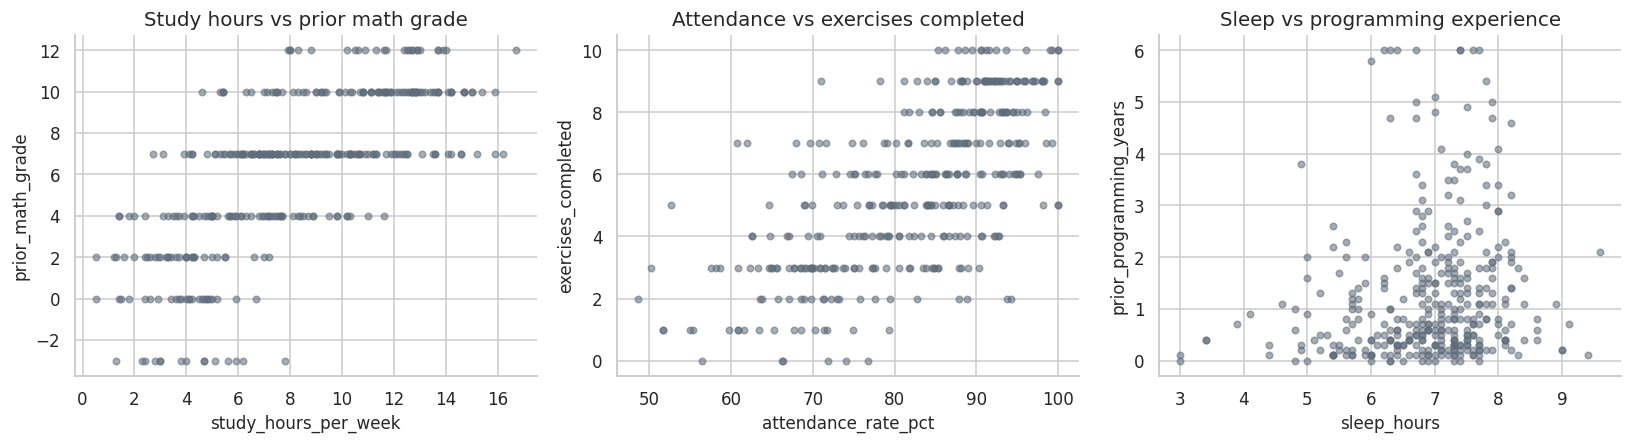

In [4]:
# --- Quick look at the features. ---

print('Summary (just the feature columns K-Means will see):')
display(df[FEATURE_COLS].describe().round(2))

fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))

axes[0].scatter(df['study_hours_per_week'], df['prior_math_grade'],
                s=18, alpha=0.55, color=COLORS['slate'])
axes[0].set_xlabel('study_hours_per_week'); axes[0].set_ylabel('prior_math_grade')
axes[0].set_title('Study hours vs prior math grade')

axes[1].scatter(df['attendance_rate_pct'], df['exercises_completed'],
                s=18, alpha=0.55, color=COLORS['slate'])
axes[1].set_xlabel('attendance_rate_pct'); axes[1].set_ylabel('exercises_completed')
axes[1].set_title('Attendance vs exercises completed')

axes[2].scatter(df['sleep_hours'], df['prior_programming_years'],
                s=18, alpha=0.55, color=COLORS['slate'])
axes[2].set_xlabel('sleep_hours'); axes[2].set_ylabel('prior_programming_years')
axes[2].set_title('Sleep vs programming experience')

plt.tight_layout(); plt.show()


**What to notice.** The first two scatter plots already hint at structure —
there seem to be a dense cluster in the lower-left (low study, low prior
math) and another in the upper-right. The third plot looks more diffuse.
That's fine — not every feature separates groups equally, which is exactly
why we'll later use *all six features at once*. K-Means combines them.


## 2. T1 — K-Means with 2 features

### The concept

We start small: only two features, `study_hours_per_week` and
`prior_math_grade`. Two features means we can plot the result on a
scatter plot and literally *see* the clusters.

Three ideas you need:

- **Distance.** K-Means uses Euclidean distance between points, so the
  scale of each feature matters. `study_hours_per_week` ranges 0–20;
  `prior_math_grade` ranges -3 to 12. If we don't rescale them, study
  hours would dominate the distance just because it has bigger numbers.
  `StandardScaler` fixes this by subtracting the mean and dividing by
  the standard deviation — every feature ends up with mean 0 and std 1.

- **Fit on scaled data, plot on raw data.** We fit the model on the
  scaled features (so distances are fair) but display centroids back in
  the *original* units (so the scatter plot makes sense). The helper
  function `scaler.inverse_transform` does that conversion.

- **`n_init`.** K-Means depends on a random initial placement of
  centroids. Sometimes it gets stuck in a poor local optimum. Setting
  `n_init=10` tells sklearn to try 10 random starts and keep the best —
  a cheap insurance policy. Always set `random_state=42` for
  reproducibility.


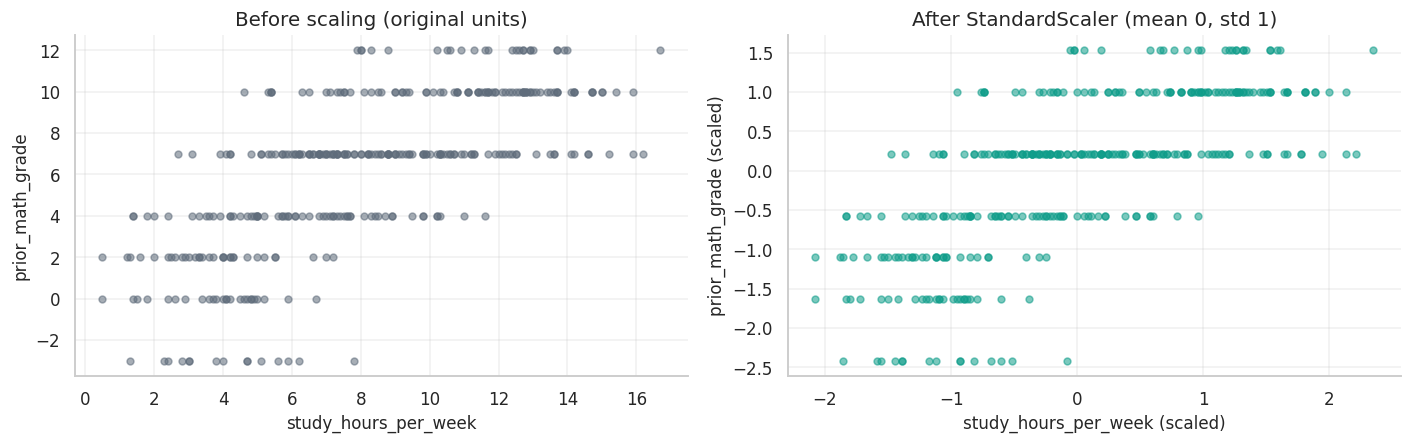

After scaling, both features have mean=0 and std=1.
  means: [-0. -0.]
  stds : [1. 1.]


In [5]:
# --- Intuition: scale the two features and see what K-Means expects. ---

demo_feats = ['study_hours_per_week', 'prior_math_grade']
X_demo_raw = df[demo_feats].values
X_demo_scaled = StandardScaler().fit_transform(X_demo_raw)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
axes[0].scatter(X_demo_raw[:, 0], X_demo_raw[:, 1], s=20, alpha=0.55,
                color=COLORS['slate'])
axes[0].set_title('Before scaling (original units)')
axes[0].set_xlabel(demo_feats[0]); axes[0].set_ylabel(demo_feats[1])

axes[1].scatter(X_demo_scaled[:, 0], X_demo_scaled[:, 1], s=20, alpha=0.55,
                color=COLORS['teal'])
axes[1].set_title('After StandardScaler (mean 0, std 1)')
axes[1].set_xlabel(f'{demo_feats[0]} (scaled)'); axes[1].set_ylabel(f'{demo_feats[1]} (scaled)')
for ax in axes:
    ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

print('After scaling, both features have mean=0 and std=1.')
print(f'  means: {X_demo_scaled.mean(axis=0).round(3)}')
print(f'  stds : {X_demo_scaled.std(axis=0).round(3)}')


### Predict before you fit

Look at the "after scaling" plot above. Before you run the next cell:

- Do you see roughly 2, 3, or 5 natural groups?
- If you had to place 3 centroids on the plot, roughly where would they go?


### T1 — K-Means on 2 features

Using the two features `study_hours_per_week` and `prior_math_grade`, fit K-Means with `k=3`. Save the cluster labels and the centroids **in original units** (not scaled) so the verify cell can plot them on a readable scatter.

**Required variables after your code runs:** `two_feats, X2_raw, scaler2, X2_scaled, kmeans2, labels_t1, centers_raw_t1`

If you're new to ML code, try first on your own, then open the hints one at
a time.

<details><summary>Hint 1 — the approach (no code yet)</summary>

Four steps:

1. Pick the two feature column names and pull them out of `df` as a NumPy array — call it `X2_raw`.
2. **Scale** the features so neither of them dominates the distance calculation. Fit a `StandardScaler` on `X2_raw` and transform it.
3. Fit K-Means with `n_clusters=3`, `random_state=42`, `n_init=10` on the scaled data.
4. Save `kmeans2.labels_` (one cluster id per student) and `scaler2.inverse_transform(kmeans2.cluster_centers_)` (the centroids in original units — so the scatter plot's axes still read 'hours' and 'Danish grade').

</details>

<details><summary>Hint 2 — the sklearn calls</summary>

- `X2_raw = df[two_feats].values` gives a `(360, 2)` array.
- `scaler2 = StandardScaler().fit(X2_raw)` — note `.fit`, not `.fit_transform`; we want the scaler object saved to `scaler2`.
  Then `X2_scaled = scaler2.transform(X2_raw)`.
- `kmeans2 = KMeans(n_clusters=3, random_state=42, n_init=10)` then `kmeans2.fit(X2_scaled)`.
- `labels_t1 = kmeans2.labels_`
- `centers_raw_t1 = scaler2.inverse_transform(kmeans2.cluster_centers_)`

</details>

<details><summary>Hint 3 — a near-solution skeleton (understand every line)</summary>

```python
two_feats = ['study_hours_per_week', 'prior_math_grade']
X2_raw = df[two_feats].values

scaler2 = StandardScaler().fit(X2_raw)
X2_scaled = scaler2.transform(X2_raw)

kmeans2 = KMeans(n_clusters=3, random_state=42, n_init=10)
kmeans2.fit(X2_scaled)

labels_t1 = kmeans2.labels_
centers_raw_t1 = scaler2.inverse_transform(kmeans2.cluster_centers_)
```

</details>


In [ ]:
##############################################################
###           TODO — T1 — K-Means on 2 features            ###
##############################################################
# Required variables:
#   two_feats, X2_raw, scaler2, X2_scaled,
#   kmeans2, labels_t1, centers_raw_t1
# See the task + hints in the markdown cell above.

raise NotImplementedError('Implement T1, then run the sanity check.')


In [ ]:
# --- Sanity check for T1 + cluster plot. ---

unique, counts = np.unique(labels_t1, return_counts=True)
sizes = dict(zip(unique.tolist(), counts.tolist()))
print(f'Cluster sizes: {sizes}   (expected roughly {{0: ~120, 1: ~145, 2: ~95}}, order may vary)')
print(f'Inertia (sum of squared distances to nearest centroid): {kmeans2.inertia_:.1f}')
print(f'   expected around 165–180. Lower = tighter clusters.')
print()
print('Centroids in original units:')
centers_df = pd.DataFrame(centers_raw_t1, columns=two_feats).round(2)
display(centers_df)

fig, ax = plt.subplots(figsize=(8, 5.5))
for i in range(3):
    pts = X2_raw[labels_t1 == i]
    ax.scatter(pts[:, 0], pts[:, 1], s=26, alpha=0.7,
               color=CLUSTER_PALETTE[i], label=f'cluster {i}')
ax.scatter(centers_raw_t1[:, 0], centers_raw_t1[:, 1], s=260, marker='X',
           color='black', edgecolor='white', linewidth=1.5, label='centroid')
ax.set_xlabel(two_feats[0]); ax.set_ylabel(two_feats[1])
ax.set_title('T1 — K-Means with k=3 on 2 features')
ax.legend()
plt.show()

# If your cluster sizes are all roughly the same size (~120 each), you
# probably forgot to scale. Check:
#   * Did you fit the scaler on X2_raw and transform to get X2_scaled?
#   * Did you fit KMeans on X2_scaled, not X2_raw?
#   * Did you pass random_state=42 and n_init=10?


**What to notice.** Three clear groups have appeared along a diagonal from
"low study + low prior grade" (bottom-left) to "high study + high prior
grade" (top-right), with a middle cluster in between. K-Means didn't know
any of those labels — it just grouped nearby points. Next, we'll do the
same thing but with *all six* features at once and see something even more
striking.


## 3. T2 — K-Means with all 6 features + the big reveal

Using all six habit features gives K-Means a fuller picture of each student.
We can't plot 6-D space directly, so instead we'll summarise each discovered
cluster with a **profile**: the mean value of every feature within that
cluster. A tidy heatmap makes the differences obvious.

Then the moment of truth. We *also* know each student's actual exam grade
(`final_grade`), a column we deliberately hid from K-Means. If the clusters
the model found really capture meaningful student types, the mean grade
should differ noticeably between clusters. If they're all around the class
average, the clustering isn't saying much.

### Predict before you fit

- Using all 6 features, will the clusters become clearer or less clear than
  with just 2 features?
- How different do you expect the mean `final_grade` of the three clusters
  to be? Same? One or two points apart? Half the scale?


### T2 — K-Means on all 6 features

Same recipe as T1 — scale, fit K-Means with `k=3`, record labels and raw-unit centroids — but this time use **all six** habit features (`FEATURE_COLS`) instead of just two.

**Required variables after your code runs:** `X6_raw, scaler6, X6_scaled, kmeans6, labels_t2, centers_raw_t2`

If you're new to ML code, try first on your own, then open the hints one at
a time.

<details><summary>Hint 1 — the approach (no code yet)</summary>

This is the same four-step recipe as T1; only the feature matrix changes from 2 columns to 6. Use a fresh scaler (`scaler6`) and fresh model (`kmeans6`) — the old ones are for 2-D data and don't know how to handle 6 columns.

Keep the same `random_state=42` and `n_init=10` so your inertia matches the sanity check.

</details>

<details><summary>Hint 2 — the sklearn calls</summary>

- `X6_raw = df[FEATURE_COLS].values`  (shape `(360, 6)`)
- `scaler6 = StandardScaler().fit(X6_raw)` then `X6_scaled = scaler6.transform(X6_raw)`.
- `kmeans6 = KMeans(n_clusters=3, random_state=42, n_init=10).fit(X6_scaled)`
- `labels_t2 = kmeans6.labels_`
- `centers_raw_t2 = scaler6.inverse_transform(kmeans6.cluster_centers_)`

</details>

<details><summary>Hint 3 — a near-solution skeleton (understand every line)</summary>

```python
X6_raw = df[FEATURE_COLS].values

scaler6 = StandardScaler().fit(X6_raw)
X6_scaled = scaler6.transform(X6_raw)

kmeans6 = KMeans(n_clusters=3, random_state=42, n_init=10)
kmeans6.fit(X6_scaled)

labels_t2 = kmeans6.labels_
centers_raw_t2 = scaler6.inverse_transform(kmeans6.cluster_centers_)
```

</details>


In [ ]:
##############################################################
###         TODO — T2 — K-Means on all 6 features          ###
##############################################################
# Required variables:
#   X6_raw, scaler6, X6_scaled,
#   kmeans6, labels_t2, centers_raw_t2
# See the task + hints in the markdown cell above.

raise NotImplementedError('Implement T2, then run the sanity check.')


In [ ]:
# --- Sanity check for T2 + cluster profiles + grade reveal. ---

sizes = pd.Series(labels_t2).value_counts().sort_index()
print(f'Cluster sizes: {sizes.to_dict()}')
print(f'Inertia: {kmeans6.inertia_:.1f}   (expected ~1000-1050)')
print()

# Profiles: mean of each feature per cluster.
prof = pd.DataFrame(centers_raw_t2, columns=FEATURE_COLS).round(2)
prof.index.name = 'cluster'
print('Cluster profiles (centroids in original units):')
display(prof)

# Visualise profiles as a heatmap (standardised across each column so
# differences are obvious, not swamped by scale).
prof_z = (prof - prof.mean()) / prof.std()
fig, ax = plt.subplots(figsize=(11, 3.4))
sns.heatmap(prof_z, annot=prof.round(1), fmt='.1f', cmap='RdBu_r',
            center=0, linewidths=0.4,
            cbar_kws={'label': 'z-score vs other clusters'}, ax=ax)
ax.set_title('Cluster profiles — which cluster leads in which habit?')
ax.set_ylabel('cluster')
plt.setp(ax.get_yticklabels(), rotation=0)
plt.tight_layout(); plt.show()


In [ ]:
# --- THE REVEAL: peek at the grades K-Means never saw. ---

reveal = df.copy()
reveal['cluster'] = labels_t2

summary = (reveal.groupby('cluster')
                 .agg(n_students=('final_grade', 'size'),
                      mean_final_grade=('final_grade', 'mean'),
                      mean_final_score=('final_score', 'mean'))
                 .round(2))
print('Hidden grade statistics per discovered cluster:')
display(summary)

fig, ax = plt.subplots(figsize=(8, 4.2))
order = summary.sort_values('mean_final_grade').index.tolist()
for rank, c in enumerate(order):
    sub = reveal[reveal['cluster'] == c]
    ax.hist(sub['final_grade'], bins=[-3.5, -1, 1, 3, 5.5, 8.5, 11, 12.5],
            alpha=0.5, color=CLUSTER_PALETTE[rank],
            label=f'cluster {c}  (mean grade = {summary.loc[c, "mean_final_grade"]:.2f})')
ax.set_xlabel('final_grade (Danish scale)'); ax.set_ylabel('students')
ax.set_title('Grade distribution per cluster — K-Means never saw these grades')
ax.legend()
plt.show()

grade_spread = summary['mean_final_grade'].max() - summary['mean_final_grade'].min()
print(f'Spread between cluster mean grades: {grade_spread:.2f} grade points.')
print(f'(Anything above 3 is a strong signal that clusters track grades.)')


**What just happened.** We fit a model on habits alone. The clusters it
found split students into groups whose mean grades differ by more than
half the Danish scale. The cluster with the lowest mean study hours has
the lowest mean grade; the cluster with the highest study hours, highest
grade. K-Means rediscovered the archetypes hiding in the data without ever
being told they existed.

**Naming the clusters.** Based on the profile heatmap, you can give each
cluster a human-readable nickname — "Dedicated achievers", "Middle of the
road", "Light effort". There's no right answer; good clustering is only
useful if you can describe what each cluster actually represents.


## 4. T3 — How many clusters? Comparing k=2, 3, 5

K-Means can't tell you *how many* clusters to ask for. You have to pick
`k`. Pick too few, and you smush together real groups (**under-clustering**).
Pick too many, and you split real groups into meaningless sub-parts
(**over-splitting**).

To build intuition we'll refit with `k=2, 3, 5` on the same 2-feature data
from T1, plot them side by side, and see what each choice looks like.

### Predict before you fit

- At `k=2`, which two clusters do you think K-Means will merge?
- At `k=5`, which single cluster will it probably split into pieces?


### T3 — Compare k=2, 3, 5 on the 2-feature data

Re-use the scaled 2-feature array `X2_scaled` from T1. Fit three K-Means models with `k=2`, `k=3`, and `k=5`, and save each fitted model in a dict so the verify cell can plot them side-by-side.

**Required variables after your code runs:** `kmeans_by_k`

If you're new to ML code, try first on your own, then open the hints one at
a time.

<details><summary>Hint 1 — the approach (no code yet)</summary>

Write a short `for` loop over `[2, 3, 5]`. Inside the loop, fit one K-Means per value of `k` (with the usual `random_state=42`, `n_init=10`) and store the fitted model in a dict keyed by `k`.

</details>

<details><summary>Hint 2 — the sklearn calls</summary>

- Start with `kmeans_by_k = {}` before the loop.
- Inside the loop:
  `km = KMeans(n_clusters=k, random_state=42, n_init=10).fit(X2_scaled)`
  `kmeans_by_k[k] = km`

Note: we fit on `X2_scaled` (the 2-feature data), **not** `X6_scaled` — this task is about making the `k` choice visually obvious on a 2-D scatter, so the plot stays human-readable.

</details>

<details><summary>Hint 3 — a near-solution skeleton (understand every line)</summary>

```python
kmeans_by_k = {}
for k in [2, 3, 5]:
    km = KMeans(n_clusters=k, random_state=42, n_init=10).fit(X2_scaled)
    kmeans_by_k[k] = km
```

</details>


In [ ]:
##############################################################
###             TODO — T3 — Compare k=2, 3, 5              ###
##############################################################
# Required variables:
#   kmeans_by_k  — dict mapping each k to its fitted KMeans model
# See the task + hints in the markdown cell above.

raise NotImplementedError('Fill in the T3 loop.')


In [ ]:
# --- Sanity check for T3 + side-by-side plot. ---

print(f"{'k':>3s}  {'inertia':>10s}  {'silhouette':>12s}")
for k, km in kmeans_by_k.items():
    sil = silhouette_score(X2_scaled, km.labels_)
    print(f'{k:>3d}  {km.inertia_:>10.1f}  {sil:>12.3f}')

fig, axes = plt.subplots(1, 3, figsize=(15, 4.2), sharex=True, sharey=True)
for ax, (k, km) in zip(axes, kmeans_by_k.items()):
    labels = km.labels_
    centers_raw = scaler2.inverse_transform(km.cluster_centers_)
    for i in range(k):
        pts = X2_raw[labels == i]
        ax.scatter(pts[:, 0], pts[:, 1], s=18, alpha=0.65,
                   color=CLUSTER_PALETTE[i % len(CLUSTER_PALETTE)])
    ax.scatter(centers_raw[:, 0], centers_raw[:, 1], s=200, marker='X',
               color='black', edgecolor='white', linewidth=1.3)
    ax.set_title(f'k = {k}  (inertia {km.inertia_:.0f})')
    ax.set_xlabel(two_feats[0])
axes[0].set_ylabel(two_feats[1])
plt.tight_layout(); plt.show()

# Expected (on 2-feature data):
#   k=2  inertia ~ 290, silhouette ~ 0.49 — merges two archetypes
#   k=3  inertia ~ 170, silhouette ~ 0.45 — clean, matches the baked-in structure
#   k=5  inertia ~ 110, silhouette ~ 0.40 — over-split, hard to describe


**What to notice.** Inertia always drops as `k` goes up — cramming more
centroids into the same data can only reduce average distance. That's why
"pick the lowest inertia" is a trap. Silhouette tells a better story
(higher = tighter, better-separated clusters) but isn't a hard law. In T4
we'll use both to pick `k` properly.


**What to notice.** The elbow isn't crisp on a real dataset — the slope
just starts bending somewhere between `k=2` and `k=3`. Silhouette peaks at
one of those two values. Both curves are saying: two or three natural
groups. We baked in three archetypes, so `k=3` is defensible, but `k=2`
would also be a reasonable simplification. K-Means *suggests*, you *choose*.


## 6. T5 — What kind of student are you?

Fill in your own study habits. We'll scale them using the same scaler we
trained for T2, find your nearest centroid using `kmeans6.predict`, and
tell you the profile and typical grade of students who look like you.

(Same disclaimer as Lab 2: synthetic data, illustrative only. Don't panic
if the answer is "Light effort.")


### T5 — what to do

1. In `my_profile` below, replace each number with a realistic value.
   Same ranges as Lab 2:
   - `study_hours_per_week`: 0–20
   - `attendance_rate_pct`: 0–100
   - `prior_math_grade`: one of `-3, 0, 2, 4, 7, 10, 12`
   - `sleep_hours`: 3–10
   - `exercises_completed`: 0–10
   - `prior_programming_years`: 0–6
2. Leave the rest of the cell alone — it scales your profile with
   `scaler6` and asks `kmeans6` which cluster you're closest to.


In [ ]:
##############################################################
###         TODO — T5 — Fill in YOUR study habits          ###
##############################################################
# Replace each value with something honest for you.

my_profile = {
    'study_hours_per_week':    11.0,   # your honest weekly study hours (0–20)
    'attendance_rate_pct':     88.0,   # your attendance %  (0–100)
    'prior_math_grade':        10,     # your previous math grade (-3, 0, 2, 4, 7, 10, 12)
    'sleep_hours':             7.5,    # your average sleep  (3–10)
    'exercises_completed':     8,      # weekly exercises you finish  (0–10)
    'prior_programming_years': 1.5,    # years of prior programming  (0–6)
}

# Don't touch below — it scales your profile and predicts your cluster.
my_x = np.array([[my_profile[c] for c in FEATURE_COLS]])
my_x_scaled = scaler6.transform(my_x)
my_cluster = int(kmeans6.predict(my_x_scaled)[0])


In [ ]:
# --- The reveal: your cluster's profile and its typical grade. ---

reveal = df.copy(); reveal['cluster'] = labels_t2
summary = (reveal.groupby('cluster')
                 .agg(n_students=('final_grade', 'size'),
                      mean_final_grade=('final_grade', 'mean'),
                      mean_final_score=('final_score', 'mean'))
                 .round(2))

# Name the clusters automatically by their mean study hours:
#   lowest study  → 'Light effort'
#   highest study → 'Dedicated achievers'
#   middle        → 'Moderate middle'
centers_df = pd.DataFrame(centers_raw_t2, columns=FEATURE_COLS)
study_ranks = centers_df['study_hours_per_week'].rank(method='first').astype(int)
name_by_rank = {1: 'Light effort', 2: 'Moderate middle', 3: 'Dedicated achievers'}
cluster_names = {c: name_by_rank[int(study_ranks[c])] for c in centers_df.index}

my_name = cluster_names[my_cluster]
my_typical_grade = summary.loc[my_cluster, 'mean_final_grade']

print('=' * 60)
print(f"You look most like cluster {my_cluster}: '{my_name}'")
print(f'Students in this cluster averaged a final grade of {my_typical_grade:.2f}')
print(f'({summary.loc[my_cluster, "n_students"]} students fall into this cluster overall.)')
print('=' * 60)
print()
print('Your cluster\'s centroid (the average member of the group):')
centroid_series = centers_df.loc[my_cluster].round(2)
centroid_series.name = 'centroid'
my_series = pd.Series(my_profile, name='you')
compare = pd.concat([my_series, centroid_series], axis=1)
compare['diff_vs_centroid'] = (compare['you'] - compare['centroid']).round(2)
display(compare)


**Experiment.** Change one number in `my_profile` — say, drop
`study_hours_per_week` from `11` to `3` — and re-run this cell and the one
above. Does your cluster switch? At what value does it tip over? That
"tipping point" is the decision boundary between two clusters, and it's
something K-Means defines implicitly for you.


## 7. T6 (bonus) — K-Means from scratch

So far sklearn has hidden the whole algorithm behind `.fit()`. Now we'll
implement it ourselves in a few lines to see there's no magic — just two
alternating steps:

1. **Assign.** For each point, find the nearest centroid (by Euclidean
   distance) and label the point with that centroid's index.
2. **Update.** For each centroid, move it to the mean of the points that
   were just assigned to it.

Repeat until labels stop changing (or a max-iteration cap is hit).

We'll run 10 iterations on the scaled 2-feature data from T1 and plot
inertia per iteration — you'll see it drops fast and then plateaus, just
like the loss curve in Lab 2's gradient descent bonus.


### T6 (bonus) — K-Means from scratch

Run the setup cell below (it picks 3 random initial centroids and creates empty state). Then write the body of the 10-iteration loop so your final `inertia_history[-1]` lands within a few points of sklearn's answer.

**Required variables after your code runs:** `centroids_scratch, labels_scratch, inertia_history`

If you're new to ML code, try first on your own, then open the hints one at
a time.

<details><summary>Hint 1 — the approach (no code yet)</summary>

Each iteration of K-Means has two alternating steps:

1. **Assign.** For every student, find the *nearest* centroid (by Euclidean distance) and label the student with that centroid's index.
2. **Update.** For every centroid, move it to the average of the students now assigned to it.

Before step 2 (but after step 1), compute the current inertia — the sum of squared distances from each point to its assigned centroid — and append it to `inertia_history`, so we can plot the convergence curve afterwards.

</details>

<details><summary>Hint 2 — the sklearn calls</summary>

Vectorised versions (faster than Python loops, and cleaner):

**Assign step.** A distance matrix from every point to every centroid:

```
dists = np.linalg.norm(
    X2_scaled[:, None, :] - centroids_scratch[None, :, :], axis=2,
)                                  # shape (n_points, n_clusters)
labels_scratch = dists.argmin(axis=1)
```

**Inertia.** Pick each point's distance to *its own* centroid, square, sum:

```
inertia = float((dists[np.arange(len(X2_scaled)), labels_scratch] ** 2).sum())
inertia_history.append(inertia)
```

**Update step.** Loop over the 3 centroids:

```
for c in range(3):
    if (labels_scratch == c).any():
        centroids_scratch[c] = X2_scaled[labels_scratch == c].mean(axis=0)
```

</details>

<details><summary>Hint 3 — a near-solution skeleton (understand every line)</summary>

```python
for it in range(10):
    dists = np.linalg.norm(
        X2_scaled[:, None, :] - centroids_scratch[None, :, :], axis=2,
    )
    labels_scratch = dists.argmin(axis=1)

    inertia = float((dists[np.arange(len(X2_scaled)), labels_scratch] ** 2).sum())
    inertia_history.append(inertia)

    for c in range(3):
        if (labels_scratch == c).any():
            centroids_scratch[c] = X2_scaled[labels_scratch == c].mean(axis=0)
```

</details>


In [ ]:
# --- Prep for from-scratch K-Means. Run this cell. ---

rng_scratch = np.random.default_rng(0)
# Pick 3 random points as initial centroids (a common init called "Forgy").
init_idx = rng_scratch.choice(len(X2_scaled), size=3, replace=False)
centroids_scratch = X2_scaled[init_idx].copy()
labels_scratch = None
inertia_history = []

print('Initial centroids (scaled):')
print(centroids_scratch.round(3))


In [ ]:
##############################################################
###        TODO — T6 (bonus) — K-Means from scratch        ###
##############################################################
# Required variables:
#   centroids_scratch — final (3, 2) array of centroid positions
#   labels_scratch    — length-N array of cluster ids (0, 1, 2)
#   inertia_history   — list of 10 inertia values, one per iteration
# See the task + hints in the markdown cell above.

for it in range(10):
    # Implement the 4 steps from the markdown cell above.
    pass

raise NotImplementedError('Fill in the K-Means loop.')


In [ ]:
# --- Sanity check + comparison with sklearn. ---

sk_inertia = kmeans_by_k[3].inertia_
print(f'From-scratch final inertia (iter 10): {inertia_history[-1]:.1f}')
print(f'Sklearn K-Means(k=3) inertia:          {sk_inertia:.1f}')
print(f'Difference: {abs(inertia_history[-1] - sk_inertia):.1f}   (expected small; < 5)')

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(range(1, 11), inertia_history, marker='o', lw=2, color=COLORS['teal'])
ax.axhline(sk_inertia, color=COLORS['red'], ls='--', label=f'sklearn = {sk_inertia:.1f}')
ax.set_xlabel('iteration'); ax.set_ylabel('inertia')
ax.set_title('From-scratch K-Means convergence')
ax.legend()
plt.show()


**What to notice.** Inertia plunges in the first two or three iterations
and then flatlines. With luck your final inertia is within a point or two
of sklearn's answer — sklearn uses a smarter initialisation (`k-means++`)
and 10 restarts under `n_init`, so it can land slightly lower. Still, your
20-line implementation does the same job. That's all K-Means is.


## Summary — what you just did

1. **Built a K-Means model from scratch with sklearn** — scaled the
   features, fit with `k=3`, plotted clusters and centroids.
2. **Extended to all 6 habit features** and described each discovered
   cluster by its centroid.
3. **Revealed that the clusters track real grade patterns** even though
   K-Means never saw the grades — the first end-to-end demonstration that
   unsupervised learning can surface genuine structure.
4. **Compared `k = 2, 3, 5`** to see under-clustering vs over-splitting.
5. **Used the elbow curve and silhouette scores** to argue for a specific
   `k` with evidence instead of guessing.
6. **Predicted your own cluster** and compared yourself to its centroid.
7. (Bonus) **Implemented K-Means by hand** in one short loop and landed
   within a point or two of sklearn's inertia.

Together with Labs 1 and 2 you've now seen the three big buckets of
classical machine learning: classification, regression, and clustering.
The same dataset, three different lenses.
